# Pytorch Force Inference Code for Overdamped Persistent Dynamics

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.

This is an adaptation of Billie's force inference code for overdamped persistent cell dynamics, converting it from tensorflow to pytorch for experimental data.

In [78]:
# Enable autoreload so module changes are automatically reloaded
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')

import importlib
import torch
import torch.nn as nn

import torch_inference_FintDot
importlib.reload(torch_inference_FintDot)
from torch_inference_FintDot import *
import functorch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# auto-reload the module

clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
clrs = ['#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d','#6e016b','#bfd3e6','#9ebcda','#8c96c6','#8c6bb1','#88419d','#6e016b']
clrs0 = ['#cc4c02','#6a51a3','#78c679','#bfd3e6']
cmap = sns.color_palette("viridis", as_cmap=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create and Train Model


In [79]:
class ForceGNN(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)
        
        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )

        self.env_net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),                          # SiLU == Swish
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv

    def _dfdr(self, edge_distances):
        """df/dr per edge via jvp with unit tangent."""
        def f(r):
            return self.interaction_net(r)  # (E, 1)
        _, dfdr = torch.func.jvp(f, (edge_distances,), (torch.ones_like(edge_distances),))
        return dfdr  # (E, 1)

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.

        Parameters:
        -----------
        node_features      : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices       : Tensor (2, E) edge connections
        edge_features      : Tensor (E, 3) [r, dx/r, dy/r]
        vel_edge_features  : Tensor (E, 3) [|dv|, dvx/|dv|, dvy/|dv|]
        return_components  : bool
            If True, return (F_total, F_drag, F_env, F_r_aggregated, F_rdot_aggregated)

        Returns:
        --------
        F_total or tuple
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0

        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        _r = getattr(self, "r_std", 1.0)
        r_std = float(np.asarray(_r).flat[0]) if np.ndim(_r) != 0 else float(_r)
        if r_std == 0.0:
            r_std = 1.0

        # Extract positions and velocities
        positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]


        # Pairwise interaction force + time derivative
        N = node_features.shape[0]
        if edge_indices.shape[1] > 0:
            src_idx = edge_indices[0, :]  # j
            tgt_idx = edge_indices[1, :]  # i  (force acts on i)

            edge_distances    = edge_features[:, 0:1]   # (E, 1)  r_ij
            edge_unit_vectors = edge_features[:, 1:3]   # (E, 2)  r_hat_ij

            # Static pairwise force: f(r) * r_hat
            F_r_scalar = self.interaction_net(edge_distances)  # (E, 1)
            F_r_vector = F_r_scalar * edge_unit_vectors        # (E, 2)

            # Per-edge velocities of i and j
            v_i = velocities[tgt_idx] #/ y_std   # (E, 2)  scaled
            v_j = velocities[src_idx] #/ y_std   # (E, 2)  scaled

            r_ij  = edge_distances.clamp(min=1e-8)    # (E, 1)
            dfdr  = self._dfdr(edge_distances)        # (E, 1)
            #tau   = self.tau_raw / r_std

            # Geometric tensor applied to an arbitrary velocity w: M(r_hat) @ w
            # = [df/dr * (r_hat . w) * r_hat] + [(f/r) * (w - r_hat(r_hat.w))]
            def _Mv(w):
                rdotw = (edge_unit_vectors * w).sum(dim=1, keepdim=True)  # (E,1)
                radial     = dfdr * rdotw * edge_unit_vectors
                transverse = (F_r_scalar / r_ij) * (w - edge_unit_vectors * rdotw)
                return (self.tau_raw/r_std)*(radial + transverse)   # (E, 2)

            F_rdot_vi_edge = _Mv(v_i)   # correlated with noise on i → drag
            F_rdot_vj_edge = _Mv(v_j)   # uncorrelated            → force-like

            # Aggregate onto target nodes
            F_r_aggregated       = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            tgt = tgt_idx.long().unsqueeze(1).expand(-1, 2)
            F_r_aggregated.scatter_add_(0, tgt, F_r_vector)
            F_rdot_vi_aggregated = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            F_rdot_vj_aggregated = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            
            F_rdot_vi_aggregated.scatter_add_(0, tgt, F_rdot_vi_edge)
            F_rdot_vj_aggregated.scatter_add_(0, tgt, F_rdot_vj_edge)
        
        # Drag term: env gradient + interparticle v_i contribution, both corrected by 2/3
        F_env = self.env_net(positions)
        Jv       = self._jvp(positions, velocities)
        vel_term =   self.tau_raw * Jv / x_std - (1.0 / self.tau_raw) * velocities / y_std #
        F_drag   = (vel_term )  * (2/3)  + F_rdot_vi_aggregated

        # Total force
        F_total = F_drag  + F_r_aggregated  + F_env - F_rdot_vj_aggregated

        if return_components:
            return F_total, F_drag,  F_r_aggregated , -F_rdot_vj_aggregated, F_env
        return F_total

In [80]:
def train_model(
    model,
    train_data,
    val_data,
    far_field_reg=0.0,
    far_field_r=70,
    max_r=100.0,
    K_far=1000,
    num_epochs=100,
    learning_rate=1e-3,
    verbose=True,
    eval_before_update=True,
    include_far_field_in_val=False,
    far_field_seed=0,
):
    """
    Train ForceGNN with consistent loss computation and flexible evaluation timing.

    eval_before_update=True:
        reports train/val losses computed on the SAME weights at epoch start.
    eval_before_update=False:
        reports train/val losses after training updates (standard behavior).
    """

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # optimizer = torch.optim.Adam([
    #     {'params': [p for n, p in model.named_parameters() if 'tau_raw' not in n],
    #     'lr': learning_rate},
    #     {'params': [model.tau_raw], 
    #     'lr': learning_rate * 10,   # tau explores 10x faster initially
    #     'name': 'tau_raw'}
    # ], lr=learning_rate)

    # Cosine annealing decays tau_raw's lr faster than the network
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer, T_max=num_epochs, eta_min=learning_rate * 0.01
    # )

    # Normalization attachment
    if len(train_data) > 0 and isinstance(train_data[0], dict):
        dp0 = train_data[0]
        if 'r_mean' in dp0 and 'r_std' in dp0:
            model.r_mean = float(dp0['r_mean'])
            model.r_std  = float(dp0['r_std']) or 1.0
        if 'y_mean' in dp0 and 'y_std' in dp0:
            model.y_mean = np.array(dp0['y_mean'], dtype=np.float32)
            model.y_std  = float(dp0['y_std']) or 1.0
        if 'x_mean' in dp0 and 'x_std' in dp0:
            model.x_mean = np.array(dp0['x_mean'], dtype=np.float32)
            model.x_std  = float(dp0['x_std']) or 1.0
    
    # Loss helpers
    def masked_mse(pred, targ, mask):
        """pred, targ: (N, 2); mask: (N,)"""
        mask = mask.float()
        num = mask.sum()
        if num == 0:
            return torch.tensor(0.0, device=pred.device), torch.tensor(0.0, device=pred.device)
        mask_exp = mask.unsqueeze(1)
        se = (pred - targ).pow(2) * mask_exp
        mse = se.sum() / (num * 2.0)
        return mse, num

    def far_field_penalty(r_far_phys):
        """r_far_phys: (K, 1) in physical units"""
        lam = float(far_field_reg)
        if lam == 0.0:
            return torch.tensor(0.0, device=next(model.parameters()).device)

        r_mean = float(getattr(model, "r_mean", 0.0))
        r_std  = float(getattr(model, "r_std",  1.0))
        if r_std == 0.0:
            r_std = 1.0

        r_far_norm = (r_far_phys)/r_std
        F_far = model.interaction_net(r_far_norm)
        return lam*F_far.pow(2).mean()

    def compute_loss_on_dataset(dataset, r_far_phys, include_far):
        total_loss  = 0.0
        total_mse   = 0.0
        total_reg   = 0.0
        total_nodes = 0.0
        n_frames_used = 0

        model.eval()
        with torch.no_grad():
            for dp in dataset:
                if 'mask' in dp and np.sum(dp['mask']) == 0:
                    continue

                pred = model(torch.tensor(dp['nodes']), torch.tensor(dp['edges']), torch.tensor(dp['edge_feat']))
                targ = torch.tensor(dp['targets']).float()

                if 'mask' in dp:
                    mask = torch.tensor(dp['mask'])
                    if not isinstance(mask, torch.Tensor):
                        mask = torch.tensor(mask, dtype=torch.float32, device=pred.device)
                    mse, num = masked_mse(pred, targ, mask)
                    if num.item() == 0:
                        continue
                else:
                    mse = (pred - targ).pow(2).mean()
                    num = torch.tensor(float(pred.shape[0]), device=pred.device)

                reg  = far_field_penalty(r_far_phys) if include_far else torch.tensor(0.0, device=pred.device)
                loss = mse + reg

                n = num.item()
                total_loss  += loss.item() * n
                total_mse   += mse.item()  * n
                total_reg   += reg.item()  * n
                total_nodes += n
                n_frames_used += 1

        if total_nodes == 0:
            return np.nan, np.nan, np.nan, 0, 0

        return (
            total_loss  / total_nodes,
            total_mse   / total_nodes,
            total_reg   / total_nodes,
            int(total_nodes),
            n_frames_used,
        ) #t

    # Training
    def train_step(dp, r_far_phys):
        model.train()
        optimizer.zero_grad()

        pred = model(torch.tensor(dp['nodes']), torch.tensor(dp['edges']), torch.tensor(dp['edge_feat']))
        targ = torch.tensor(dp['targets']).float()

        if 'mask' in dp:
            mask = torch.tensor(dp['mask'])
            if not isinstance(mask, torch.Tensor):
                mask = torch.tensor(mask, dtype=torch.float32, device=pred.device)
            mse, num = masked_mse(pred, targ, mask)
        else:
            mse = (pred - targ).pow(2).mean()
            num = torch.tensor(float(pred.shape[0]), device=pred.device)

        reg  = far_field_penalty(r_far_phys)
        loss = mse + reg

        loss.backward()
        optimizer.step()

        return reg, loss, mse, num 

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse":  [], "val_mse":  [],
        "train_reg":  [], "val_reg":  [],
        "tau_raw":    [],
    }

    if verbose:
        print(f"Training for {num_epochs} epochs...")
        print("=" * 60)

    device = next(model.parameters()).device

    for epoch in range(num_epochs):
        r_far_phys = far_field_r + (max_r - far_field_r)*torch.rand(
            K_far, 1, dtype=torch.float32, device=device,
            generator=torch.Generator(device=device).manual_seed(far_field_seed + epoch)
        )
        # Evaluate BEFORE updates
        if eval_before_update:
            trL, trM, trR, trN, trF = compute_loss_on_dataset(train_data, r_far_phys, include_far=True)
            vaL, vaM, vaR, vaN, vaF = compute_loss_on_dataset(val_data,   r_far_phys, include_far=include_far_field_in_val)
        else:
            trL = trM = trR = vaL = vaM = vaR = None

        # Train one epoch
        total_loss  = 0.0
        total_mse   = 0.0
        total_reg   = 0.0
        total_nodes = 0.0

        for dp in train_data:
            if 'mask' in dp and np.sum(dp['mask']) == 0:
                continue

            reg, loss, mse, num = train_step(dp, r_far_phys) #reg, 
            n = num.item()
            if n == 0:
                continue

            total_loss  += loss.item() * n
            total_mse   += mse.item()  * n
            total_reg   += reg.item()  * n
            total_nodes += n

        train_loss_after = (total_loss / total_nodes) if total_nodes > 0 else np.nan
        train_mse_after  = (total_mse  / total_nodes) if total_nodes > 0 else np.nan
        train_reg_after  = (total_reg  / total_nodes) if total_nodes > 0 else np.nan
        
        # Evaluate AFTER updates
        if not eval_before_update:
            trL, trM, trR, _, _ = compute_loss_on_dataset(train_data, r_far_phys, include_far=True) #
            vaL, vaM, vaR, _, _ = compute_loss_on_dataset(val_data,   r_far_phys, include_far=include_far_field_in_val) #
        #scheduler.step()
        history["train_loss"].append(trL)
        history["val_loss"].append(vaL)
        history["train_mse"].append(trM)
        history["val_mse"].append(vaM)
        history["train_reg"].append(trR)
        history["val_reg"].append(vaR)
        history["tau_raw"].append(
            model.tau_raw.item() if hasattr(model, 'tau_raw') else np.nan
        )

        if verbose and (epoch % 10 == 0 or epoch == num_epochs - 1):
            #tau_lr = optimizer.param_groups[1]['lr']
            #print(f"... Tau_raw={tau_val:.6f}, Tau_lr={tau_lr:.6f}")
            timing = "PRE" if eval_before_update else "POST"
            tau_val = model.tau_raw.item() if hasattr(model, 'tau_raw') else float('nan')
            print(
                f"Epoch {epoch:3d} [{timing}-update metrics]: "
                f"Train L={trL:.6f} (mse={trM:.6f}, reg={trR:.6f}) | "
                f"Val L={vaL:.6f} (mse={vaM:.6f}, reg={vaR:.6f}) | "
                f"Train-step avg(after)={train_loss_after:.6f} | "
                f"Tau_raw={tau_val:.6f}|" #, Tau_lr={tau_lr:.6f}"
            )

    return model, history

In [81]:
def create_model(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

In [206]:

datasave = "//Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/models/"
dataINsave = "//Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/dataIN/"

frame = 1
delta_t = 0.167 #in minutes, frame rate is 10s
dt = delta_t*frame
T_weak = True #False
T_Naive = False #True
tau = 4
NumEpochs = 100
tau_mem0 = 10
datadir = "//Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Data_CSVs/"
dataname='master_tracks_1-2Pulse1.csv'
#dataname='master_tracks_1-5Pulse6.csv'
data = load_data(datadir, dataname)
min_frame = data['frame'].min()
max_frame = data['frame'].max()
data['x']=data['x']-np.mean(data['x'])
data['y']=data['y']-np.mean(data['y'])
#data = load_data(AltUD_Data, name)
version = 0
Time1,Time2 = 300,700
data = data[data['frame'] > min_frame+Time1]
data = data[data['frame'] < min_frame+Time2]
dt = delta_t*frame
r_cut=100
if T_weak == True:
    derivative = "weak"
else:
    derivative = "naive"
print("length of data: ", len(data))
print("Total unique particles: ", len(data['particle'].unique()))
print("for naive derivative, should be losing 2x the number of particles",len(data)-len(data['particle'].unique())*2)
min_frame = data['frame'].min()
max_frame = data['frame'].max()
#data = data[data['frame'] > max_frame-140]
data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = tau)
dataset_ = prepare_dataset(data_clean, cutoff=r_cut, max_frames=700,use_neighbor_list=False)
train_data, val_data, test_data, __ = split_dataset(dataset_)

Data loaded: (101164, 4)
Columns: ['particle', 'frame', 'x', 'y']
length of data:  51162
Total unique particles:  2241
for naive derivative, should be losing 2x the number of particles 46680
Calculating derivatives...
Processing 2241 particles...
Calculating weak derivatives...
In Compute Weak Derivatives:         particle  frame           x           y         vx         vy   ax  \
27347      1803    327  465.176807  292.027169 -52.510364 -35.928144  0.0   
27349      1803    326  456.176807  296.027169 -33.164440 -52.510364  0.0   
27363      1803    307  472.176807  324.027169  -0.000000   2.763703  0.0   
27366      1803    330  465.176807  299.027169  11.054813  11.054813  0.0   
27369      1803    331  467.176807  294.027169  -5.527407  16.582220  0.0   

        ay  _tmp_vx  _tmp_vy  
27347  0.0      0.0      0.0  
27349  0.0      0.0      0.0  
27363  0.0      0.0      0.0  
27366  0.0      0.0      0.0  
27369  0.0      0.0      0.0  
  Weak derivative statistics (tau=4):
    

In [208]:
import pickle

splits_name = ("dataSplits_1-2Pulse1"
               + "From_t1=" + str(Time1) + "_t2=" + str(Time2)
               + "Rcut" + str(r_cut)+derivative+".pkl")

# splits_name = ("dataSplits_1-5Pulse6"
#                + "From_t1=" + str(Time1) + "_t2=" + str(Time2)
#                + "Rcut" + str(r_cut) + ".pkl")
with open(dataINsave + splits_name, 'wb') as f:
    pickle.dump({'train': train_data, 'val': val_data, 'test': test_data}, f)
print("Saved data splits to:", dataINsave + splits_name)


Saved data splits to: //Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/dataIN/dataSplits_1-2Pulse1From_t1=300_t2=700Rcut100weak.pkl


In [209]:
# Create model
tau_mem0 = 0.3
model = create_model(hidden_dim=64, tau_init=tau_mem0)

# Train model
Epochs = 50
far_field_strength = 1000.0
far_field_r = 90.0
max_r = 100.0
K_far = 1000
model, history = train_model(model,train_data,val_data,far_field_reg=far_field_strength,far_field_r=far_field_r,max_r=max_r,K_far=K_far,num_epochs=Epochs,learning_rate=1e-3,verbose=True,include_far_field_in_val=False,far_field_seed=1)

#model, history = train_model(model, train_data, val_data, num_epochs=100)


ForceGNN model created with hidden_dim=64
Training for 50 epochs...
Epoch   0 [PRE-update metrics]: Train L=10.104936 (mse=1.231045, reg=8.873891) | Val L=1.224580 (mse=1.224580, reg=0.000000) | Train-step avg(after)=1.305777 | Tau_raw=0.314379|
Epoch  10 [PRE-update metrics]: Train L=1.019380 (mse=0.991503, reg=0.027878) | Val L=0.970938 (mse=0.970938, reg=0.000000) | Train-step avg(after)=0.996100 | Tau_raw=0.314871|
Epoch  20 [PRE-update metrics]: Train L=0.992125 (mse=0.990462, reg=0.001663) | Val L=0.969351 (mse=0.969351, reg=0.000000) | Train-step avg(after)=0.994456 | Tau_raw=0.315204|
Epoch  30 [PRE-update metrics]: Train L=0.990127 (mse=0.990104, reg=0.000022) | Val L=0.968703 (mse=0.968703, reg=0.000000) | Train-step avg(after)=0.992448 | Tau_raw=0.315422|
Epoch  40 [PRE-update metrics]: Train L=0.990936 (mse=0.989862, reg=0.001074) | Val L=0.968617 (mse=0.968617, reg=0.000000) | Train-step avg(after)=0.991589 | Tau_raw=0.316065|
Epoch  49 [PRE-update metrics]: Train L=0.9893

In [210]:
print(derivative)
name = "modelFenvPytorch"+"1-2Pulse1"+"From_t1="+str(Time1)+"_t2="+str(Time2)+"TauInit"+str(tau_mem0)+"Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs_"+derivative
#name = "modelFenvPytorch"+"1-5Pulse6"+"From_t1="+str(Time1)+"_t2="+str(Time2)+"TauInit"+str(tau_mem0)+"Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs"+"_deriv"+str(derivative)
save_model(model, datasave + name, history=history)

weak
Model weights saved to: //Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/models/modelFenvPytorch1-2Pulse1From_t1=300_t2=700TauInit0.3Rcut100_FarFieldR100_50Epochs_weak.pt
Model config saved to:  //Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/models/modelFenvPytorch1-2Pulse1From_t1=300_t2=700TauInit0.3Rcut100_FarFieldR100_50Epochs_weak_config.json
Normalisation stats saved to: //Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/models/modelFenvPytorch1-2Pulse1From_t1=300_t2=700TauInit0.3Rcut100_FarFieldR100_50Epochs_weak_norm.json
History saved to: //Users/billiemeadowcroft/Dropbox/PostDocCode/ElizabethData/Inference/models/modelFenvPytorch1-2Pulse1From_t1=300_t2=700TauInit0.3Rcut100_FarFieldR100_50Epochs_weak_history.json


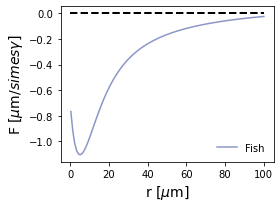

In [211]:
# Get force at a specific distance
sigma = 1.5
l_da = 0.1
rcut = sigma*2+1
epsilon = 0.5
r_arr = np.linspace(0.3,100,100)
force_infer = []
force_infer_stem=[]
force_true = []
for r in r_arr:
    force_infer.append(get_force_at_distance(model, r))

fig,ax  = plt.subplots(figsize = (4,3))
scaleF = 1
ax.plot(r_arr,np.multiply(force_infer,1),color = clrs[2],linestyle = '-',label = 'Fish')
#ax.plot(r_arr,np.multiply(force_infer_stem,1),color = clrs[0],linestyle = '-',label = 'Stem')
ax.set_xlabel('r [$\\mu$m]',fontsize = 14)
ax.set_ylabel('F [$\\mu$m$/s \times \\gamma$]',fontsize = 14)
ax.plot([0,100],[0,0],color = 'black',linestyle = '--',linewidth = 2)
#ax.set_ylim([-1,2])
ax.legend(frameon = False)
fig.tight_layout()

In [212]:
print(tau_mem0)
tau_mem0=0.2

0.3


In [213]:
# Save#
#name = "modelFenvPytorch_TauInit"+str(tau_mem0)+"_MDCK_Stem_Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs_NoFenv_FintDot"+str(version)
#name = "modelFenvPytorch_TauInit"+str(tau_mem0)+"_MDCK_Stem_Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs_NoFenv"+str(version)


# Load
#loaded_model = load_model(datasave + name)
# or without a config file:
#loaded_model = load_model(datasave + name, hidden_dim=64)

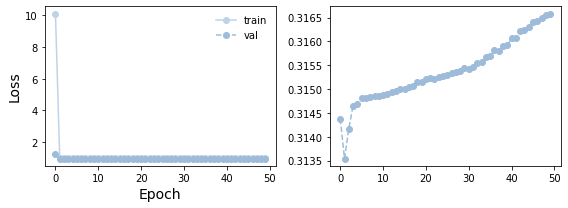

In [214]:
# Plot training history
tau_mem0=10
gamma0=1

fig,ax  = plt.subplots(1,2,figsize = (8,3))
ax[0].plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
ax[0].plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val',marker = 'o')
ax[1].plot(history['tau_raw'],color = clrs[1],linestyle = '--',label = 'tau',marker = 'o')
#ax[1].plot([0,len(history['tau_raw'])],[tau_mem0,tau_mem0],color = 'black',linestyle = '--',label = r"True force gradient $\nabla_x F$")
ax[0].legend(frameon = False)
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel('Loss',fontsize = 14)
fig.tight_layout()

In [215]:
def get_force_environment(model, x, y):
    if not hasattr(model, 'env_net') or model.env_net is None:
        raise AttributeError(
            "This model does not have an env_net (F_env component). "
            "The model was trained without environmental forces."
        )

    x_mean = np.array(getattr(model, "x_mean", [0.0, 0.0]), dtype=np.float32)
    x_std  = float(getattr(model, "x_std", 1.0))
    if x_std == 0.0:
        x_std = 1.0

    # Normalise query position
    x_norm = (float(x) - float(x_mean[0])) / x_std
    y_norm = (float(y) - float(x_mean[1])) / x_std

    model.eval()
    with torch.no_grad():
        inp = torch.tensor([[x_norm, y_norm]], dtype=torch.float32,
                           device=next(model.parameters()).device)
        F_env_norm = model.env_net(inp).cpu().numpy()[0, :]

    # De-normalise output to physical units
    _y = getattr(model, "y_std", 1.0)
    y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
    if y_std == 0.0:
        y_std = 1.0

    return y_std * F_env_norm

In [216]:
def save_model(model, filepath, history=None):
    """
    Save a trained ForceGNN (PyTorch) model.

    Saves three files:
      <filepath>.pt          – model weights (state_dict)
      <filepath>_config.json – architecture hyperparameters needed to reconstruct the model
      <filepath>_norm.json   – normalisation statistics stored on the model
      <filepath>_history.json – training history (optional, if history is provided)

    Parameters
    ----------
    model : ForceGNN
        Trained model.
    filepath : str
        Base path (no extension). Extensions are added automatically.
    history : dict, optional
        Training history returned by train_model().
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    # --- weights ---
    torch.save(model.state_dict(), filepath)
    print(f"Model weights saved to: {filepath}")

    # --- architecture config ---
    # Infer hidden_dim from the first Linear layer of interaction_net
    hidden_dim = 64 #model.interaction_net[0].out_features
    tau_init   = float(model.tau_raw.detach().cpu())   # save current learned value as init hint
    config = {
        "hidden_dim": int(hidden_dim),
        "tau_init":   tau_init,
    }
    config_path = filepath.replace('.pt', '_config.json')
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"Model config saved to:  {config_path}")

    # --- normalisation stats ---
    def _to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        return float(v)

    norm = {
        "r_mean": _to_list(getattr(model, "r_mean", 0.0)),
        "r_std":  _to_list(getattr(model, "r_std",  1.0)),
        "y_mean": _to_list(getattr(model, "y_mean", np.array([0.0, 0.0]))),
        "y_std":  _to_list(getattr(model, "y_std",  np.array([1.0, 1.0]))),  # was scalar default
        "x_mean": _to_list(getattr(model, "x_mean", np.array([0.0, 0.0]))),
        "x_std":  _to_list(getattr(model, "x_std",  1.0)),
    }
    norm_path = filepath.replace('.pt', '_norm.json')
    with open(norm_path, 'w') as f:
        json.dump(norm, f, indent=2)
    print(f"Normalisation stats saved to: {norm_path}")

    # --- history ---
    if history is not None:
        history_path = filepath.replace('.pt', '_history.json')
        # Convert any numpy/torch scalars to plain Python floats for JSON
        clean = {}
        for k, v in history.items():
            if isinstance(v, (list, tuple)):
                clean[k] = [float(x) if not isinstance(x, str) else x for x in v]
            else:
                clean[k] = float(v) if not isinstance(v, str) else v
        with open(history_path, 'w') as f:
            json.dump(clean, f, indent=2)
        print(f"History saved to: {history_path}")


def load_model(filepath, hidden_dim=None, tau_init=1.0, device=None):
    """
    Load a saved ForceGNN (PyTorch) model.

    Looks for:
      <filepath>.pt           – weights
      <filepath>_config.json  – architecture config (optional if hidden_dim is passed)
      <filepath>_norm.json    – normalisation stats (optional)

    Parameters
    ----------
    filepath : str
        Path to the .pt weights file (with or without the .pt extension).
    hidden_dim : int, optional
        Hidden dimension used when the model was created. If None, reads from
        the saved config file. Required if no config file exists.
    tau_init : float, optional
        Only used as a fallback if no config file is found.
    device : torch.device or str, optional
        Device to load weights onto. Defaults to CPU.

    Returns
    -------
    ForceGNN
        Loaded model in eval() mode.
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    if device is None:
        device = torch.device('cpu')

    # --- architecture config ---
    config_path = filepath.replace('.pt', '_config.json')
    try:
        with open(config_path, 'r') as f:
            config = json.load(f)
        hidden_dim = hidden_dim or config["hidden_dim"]
        tau_init   = config.get("tau_init", tau_init)
        print(f"Loaded config from: {config_path}")
    except FileNotFoundError:
        if hidden_dim is None:
            raise ValueError(
                f"No config file found at {config_path} and hidden_dim not provided. "
                "Pass hidden_dim explicitly."
            )
        print(f"No config file found; using hidden_dim={hidden_dim}, tau_init={tau_init}")

    # --- reconstruct model ---
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)

    # --- load weights ---
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Weights loaded from: {filepath}")

    # --- normalisation stats ---
    norm_path = filepath.replace('.pt', '_norm.json')
    try:
        with open(norm_path, 'r') as f:
            norm = json.load(f)
        model.r_mean = float(norm.get("r_mean", 0.0))
        model.r_std  = float(norm.get("r_std",  1.0)) or 1.0
        model.y_mean = np.array(norm.get("y_mean", [0.0, 0.0]), dtype=np.float32)
        model.y_std = norm.get("y_std", 1.0)
        if isinstance(model.y_std, list):
            model.y_std = np.array(model.y_std, dtype=np.float32)
        else:
            model.y_std = float(model.y_std) or 1.0
        #model.y_std  = float(norm.get("y_std",  1.0)) or 1.0
        model.x_mean = np.array(norm.get("x_mean", [0.0, 0.0]), dtype=np.float32)
        model.x_std  = float(norm.get("x_std",  1.0)) or 1.0
        print(f"Normalisation restored: r_mean={model.r_mean:.6g}, r_std={model.r_std:.6g}")
    except FileNotFoundError:
        print(f"No normalisation file at {norm_path}; using defaults.")

    model.to(device)
    model.eval()
    print(f"  hidden_dim={hidden_dim}, tau={float(model.tau_raw.detach()):.6f}")
    return model

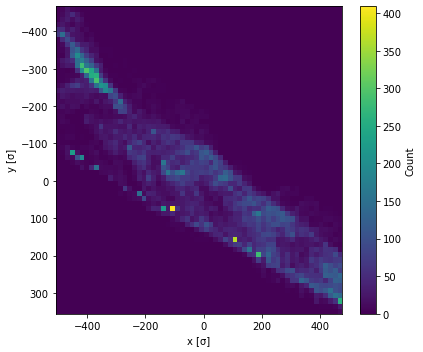

In [217]:
fig, ax = plt.subplots(figsize=(6, 5))
_, _, _, im = ax.hist2d(data['x'], data['y'], bins=60, cmap='viridis') #, vmin=0, vmax=100)
fig.colorbar(im, ax=ax, label='Count')
ax.set_xlabel('x [σ]')
ax.set_ylabel('y [σ]')
#ax.set_ylim([x_arr[0], x_arr[-1]])
#ax.set_xlim([x_arr[0], x_arr[-1]])
#ax.set_title(f'Position density (α={alpha})')
fig.tight_layout()
ax.invert_yaxis()
fig.savefig('density_heatmap.png', dpi=150)

In [218]:
def get_force_at_distance(model, r):
    """
    Get the learned pairwise force magnitude at a given distance.
    
    Parameters:
    -----------
    model : ForceGNN
        Trained model
    r : float
        Distance value
    
    Returns:
    --------
    float
        Force magnitude F_r(r)
    """

    model.eval()
    r_mean = float(getattr(model, "r_mean", 0.0))
    r_std  = float(getattr(model, "r_std", 1.0))
    if r_std == 0.0:
        r_std = 1.0
    _y = getattr(model, "y_std", 1.0)
    y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
    if y_std == 0.0:
        y_std = 1.0
    #print(r_std)
    r_norm = (r) / r_std #- r_mean
    
    F_norm = model.interaction_net(torch.tensor([[r_norm]], dtype=torch.float32)).item()
    with torch.no_grad():
        return y_std * F_norm

## Evaluate model, find $R^2$

In [219]:
def evaluate_model(model, test_data, verbose=True):
    test_predictions_masked = []
    test_targets_masked = []
    index_map = []  # (frame_idx, node_idx) for each masked row

    total_nodes = 0
    masked_nodes = 0

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            predictions = model(
                torch.tensor(data_point['nodes']),
                torch.tensor(data_point['edges']),
                torch.tensor(data_point['edge_feat'])
            ).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            mask_indices = mask == 1.0
            #mask_indices = mask.astype(bool)

            masked_pred = predictions[mask_indices]
            masked_targ = targets[mask_indices]

            test_predictions_masked.append(masked_pred)
            test_targets_masked.append(masked_targ)

            # record original indices
            node_ids = np.where(mask_indices)[0]
            index_map.extend([(frame_idx, int(n)) for n in node_ids])

            total_nodes  += len(predictions)
            masked_nodes += int(np.sum(mask_indices))

    if len(test_predictions_masked) > 0:
        test_predictions_flat = np.vstack(test_predictions_masked)
        test_targets_flat     = np.vstack(test_targets_masked)
        num_masked_nodes      = len(test_predictions_flat)

        if num_masked_nodes > 0:
            squared_errors = (test_predictions_flat - test_targets_flat) ** 2
            test_mse_x = np.mean(squared_errors[:, 0])
            test_mse_y = np.mean(squared_errors[:, 1])
            test_mse   = np.mean(squared_errors)
            test_mae   = np.mean(np.abs(test_predictions_flat - test_targets_flat))
        else:
            test_mse_x = test_mse_y = test_mse = test_mae = 0.0
    else:
        test_predictions_flat = np.zeros((0, 2), dtype=np.float32)
        test_targets_flat     = np.zeros((0, 2), dtype=np.float32)
        index_map        = []
        num_masked_nodes = 0
        test_mse_x = test_mse_y = test_mse = test_mae = 0.0

    if verbose:
        print(f"\nTest Set Evaluation (masked nodes only):")
        print(f"  Total nodes in test set: {total_nodes}")
        print(f"  Masked nodes (mask=1): {masked_nodes} ({100*masked_nodes/total_nodes:.1f}%)")
        print(f"  MSE (x-direction): {test_mse_x:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (y-direction): {test_mse_y:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (overall): {test_mse:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MAE: {test_mae:.6f} (on {num_masked_nodes:.0f} masked nodes)")

    return {
        'mse':              test_mse,
        'mse_x':            test_mse_x,
        'mse_y':            test_mse_y,
        'mae':              test_mae,
        'predictions':      test_predictions_flat,
        'targets':          test_targets_flat,
        'index_map':        index_map,
        'num_masked_nodes': num_masked_nodes,
        'total_nodes':      total_nodes,
    }

In [220]:
evaluation = evaluate_model(model,val_data,verbose = True)
predictions = evaluation['predictions']
targets = evaluation['targets']
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")


Test Set Evaluation (masked nodes only):
  Total nodes in test set: 7619
  Masked nodes (mask=1): 4669 (61.3%)
  MSE (x-direction): 1.046400 (on 4669 masked nodes)
  MSE (y-direction): 0.889845 (on 4669 masked nodes)
  MSE (overall): 0.968123 (on 4669 masked nodes)
  MAE: 0.741634 (on 4669 masked nodes)
R^2 for ax: 0.2639
R^2 for ay: 0.2574
Average R^2: 0.2606


In [221]:
y_std = float(model.y_std)
rsq_ax = 1 - (evaluation['mse_x'] * y_std**2) / np.var(targets[:,0] * y_std)
rsq_ay = 1 - (evaluation['mse_y'] * y_std**2) / np.var(targets[:,1] * y_std)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")

R^2 for ax: 0.2639
R^2 for ay: 0.2574
Average R^2: 0.2606


In [222]:
print("Var(targets):", np.var(targets))
print("Var(predictions):", np.var(predictions))
print("MSE:", evaluation['mse'])

Var(targets): 1.3098608
Var(predictions): 0.3297632
MSE: 0.96812254


## Query environmental force

In [223]:
def estimate_noise_magnitude(model, test_data):
    all_residuals = []
    all_masks = []

    model.eval()
    with torch.no_grad():
        for data_point in test_data:
            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            Y_pred = model(node_features, edge_indices, edge_features).cpu().numpy()  # (N, 2)

            Y_true = data_point['targets']
            if isinstance(Y_true, torch.Tensor):
                Y_true = Y_true.cpu().numpy()

            resid = Y_true - Y_pred  # (N, 2)
            all_residuals.append(resid)

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
                all_masks.append(mask)
            else:
                all_masks.append(np.ones(len(resid), dtype=np.float32))

    all_residuals = np.vstack(all_residuals)
    all_masks     = np.concatenate(all_masks)

    mask_indices     = all_masks == 1.0
    masked_residuals = all_residuals[mask_indices]

    if len(masked_residuals) == 0:
        print("Warning: No masked nodes found in test data for noise estimation")
        return {
            "per_dim_var":  np.array([0.0, 0.0]),
            "per_dim_std":  np.array([0.0, 0.0]),
            "overall_rms":  0.0,
            "num_samples":  0,
            "num_frames":   len(test_data),
            "mean_residual": np.array([0.0, 0.0]),
        }

    num_samples = len(masked_residuals)
    mean_r      = np.mean(masked_residuals, axis=0)
    var_r       = np.sum((masked_residuals - mean_r)**2, axis=0) / (num_samples - 1) if num_samples > 1 else np.zeros(2)
    std_r       = np.sqrt(var_r)
    overall_rms = np.sqrt(np.mean(np.sum(masked_residuals**2, axis=1)))

    return {
        "per_dim_var":        var_r,
        "per_dim_std":        std_r,
        "overall_rms":        float(overall_rms),
        "num_samples":        num_samples,
        "num_frames":         len(test_data),
        "mean_residual":      mean_r,
        "sum_residuals_sq_x": np.sum(masked_residuals[:, 0]**2),
        "sum_residuals_sq_y": np.sum(masked_residuals[:, 1]**2),
    }

def evaluate_model_frames(model, test_data, verbose=True):
    rows = []

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            frame_id = data_point.get('frame', frame_idx)

            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            predictions = model(node_features, edge_indices, edge_features).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            nodes = data_point['nodes']

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            if 'particle_ids' in data_point:
                node_ids = data_point['particle_ids']
            else:
                node_ids = np.arange(len(predictions))

            mask_indices = mask == 1.0

            theta_pred   = np.arctan2(predictions[:, 1], predictions[:, 0])
            theta_true   = np.arctan2(targets[:, 1],     targets[:, 0])
            errors_theta = np.abs(theta_pred - theta_true)
            errors_x     = predictions[:, 0] - targets[:, 0]
            errors_y     = predictions[:, 1] - targets[:, 1]
            errors       = np.sqrt(errors_x**2 + errors_y**2)

            num_neighbors_arr = data_point['num_neighbors']
            nn_r_arr          = data_point['nn_r']

            for i in range(len(predictions)):
                if mask_indices[i]:
                    rows.append({
                        'frame':         frame_id,
                        'node_id':       int(node_ids[i]) if hasattr(node_ids[i], '__int__') else node_ids[i],
                        'x':             float(nodes[i, 0]),
                        'y':             float(nodes[i, 1]),
                        'vx':            float(nodes[i, 2]),
                        'vy':            float(nodes[i, 3]),
                        'num_neighbors': float(num_neighbors_arr[i]),
                        'nn_r':          float(nn_r_arr[i]),
                        'error':         float(errors[i]),
                        'error_theta':   float(errors_theta[i]),
                        'error_x':       float(errors_x[i]),
                        'error_y':       float(errors_y[i]),
                        'pred_x':        float(predictions[i, 0]),
                        'pred_y':        float(predictions[i, 1]),
                        'target_x':      float(targets[i, 0]),
                        'target_y':      float(targets[i, 1]),
                    })

    df = pd.DataFrame(rows)

    if verbose:
        if len(df) > 0:
            print(f"\nFrame-based Evaluation:")
            print(f"  Total rows:     {len(df)}")
            print(f"  Unique frames:  {df['frame'].nunique()}")
            print(f"  Unique nodes:   {df['node_id'].nunique()}")
            print(f"  Mean error:     {df['error'].mean():.6f}")
            print(f"  Median error:   {df['error'].median():.6f}")
            print(f"  Std error:      {df['error'].std():.6f}")
        else:
            print("\nFrame-based Evaluation: No data (all nodes may have been masked out)")

    return df

In [224]:
#max_dist = 1
r_cut = 100 # 120
x_min =data['x'].min()
x_max = data['x'].max()
y_min =data['y'].min()
y_max = data['y'].max()

x_arr = np.linspace(x_min,x_max,40)
y_arr = np.linspace(y_min,y_max,40)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = np.multiply(get_force_environment(model, y, x),1)

r_arr = np.linspace(0.3,r_cut,100)
force_infer = []
force_true = []
for r in r_arr:
    force_infer.append(get_force_at_distance(model, r))

r_arr_plot = np.multiply(r_arr,1)
# === 1) Magnitude of the force ===
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')

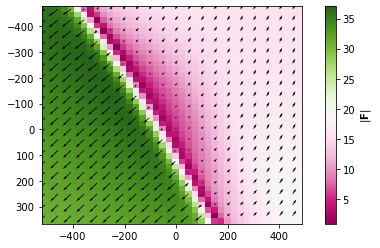

In [225]:
fig,ax  = plt.subplots(1,figsize = (8,4))
scaleF = 1
counts, _, _ = np.histogram2d(
    data['x'], data['y'],
    bins=[len(x_arr), len(y_arr)],
    range=[[x_arr[0], x_arr[-1]], [y_arr[0], y_arr[-1]]],
)
sparse_mask = counts <= 10
#F_mag_infer_masked = np.where(sparse_mask, np.nan, np.linalg.norm(F_mag, axis=2))

pcm = ax.pcolormesh(X, Y, F_mag, shading='auto', cmap='PiYG')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'$|\mathbf{F}|$')

# === 3) Quiver on top ===
# (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 20, 1)
sy = max(len(y_arr) // 20, 1)

ax.quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    F_env_infer[::sx, ::sy, 0],
    F_env_infer[::sx, ::sy, 1],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=None,   # or a number if you want to shrink arrows
    width=0.003
)
ax.invert_yaxis()
ax.set_aspect('equal')

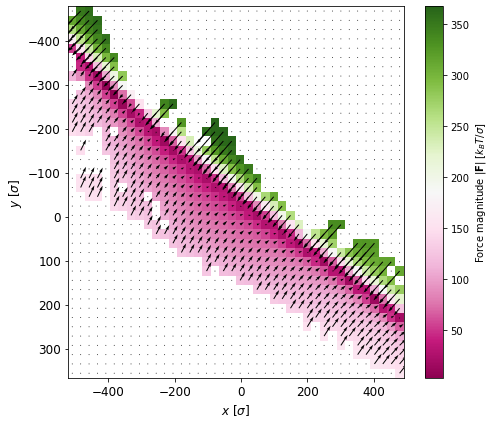

In [226]:

F_infer = np.zeros((len(x_arr), len(y_arr), 2))
for i, x in enumerate(x_arr):
    for j, y in enumerate(y_arr):
        F_infer[i, j] = get_force_environment(model, x, y) * tau_mem0 * gamma0

F_mag_infer = np.where(sparse_mask, np.nan, np.linalg.norm(F_infer, axis=2))
F_vec = F_infer.copy(); F_vec[sparse_mask] = 0.0
FS=(7,6)
FONTSIZE =12
fig, ax = plt.subplots(figsize=FS)
pcm = ax.pcolormesh(X, Y, F_mag_infer, shading='auto', cmap='PiYG')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'Force magnitude $|\mathbf{F}|$ $[k_BT/\sigma]$', fontsize=FONTSIZE - 2)
cbar.ax.tick_params(labelsize=FONTSIZE - 2)
ax.quiver(X, Y, F_vec[..., 0], F_vec[..., 1],
          color='k', angles='xy', scale_units='xy', scale=5, width=0.003)
ax.set_xlabel(r'$x$ [$\sigma$]', fontsize=FONTSIZE)
ax.set_ylabel(r'$y$ [$\sigma$]', fontsize=FONTSIZE)
ax.invert_yaxis()
ax.tick_params(labelsize=FONTSIZE)
#ax.set_title(r'Underdamped model', fontsize=FONTSIZE)
fig.tight_layout()

{'per_dim_var': array([1.0464147 , 0.88994616], dtype=float32), 'per_dim_std': array([1.0229441 , 0.94336957], dtype=float32), 'overall_rms': 1.3914903402328491, 'num_samples': 4669, 'num_frames': 59, 'mean_residual': array([-0.01443821, -0.00941018], dtype=float32), 'sum_residuals_sq_x': 4885.6406, 'sum_residuals_sq_y': 4154.6885}
1.0
1.0


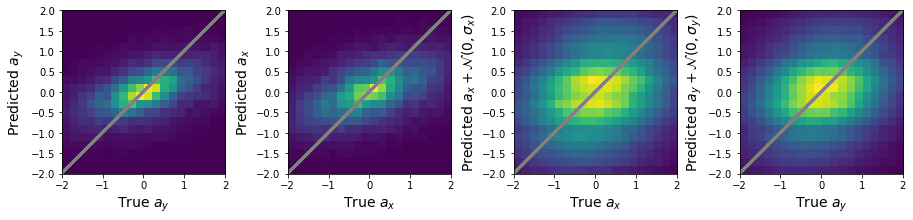

In [227]:
# visualise the y_pred vs y_true and compare against a noise-floor reference:
# targets vs targets + N(0, sigma). A perfect model, given the inferred noise,
# would reproduce the distribution in the right panels. If the left panels look
# tighter OR similar to the right panels, the model is at/near the noise floor.
#evaluation = evaluate_model(model, val_data, verbose=False)
evaluation = evaluate_model(model, __, verbose=False)
predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model, val_data)
print(Overall_noise)

rng = np.random.default_rng(0)
n_draws = 20  # multiple draws per target so the reference heatmap isn't sparser

sigma_x, sigma_y = Overall_noise['per_dim_std']

# Noise-floor reference: tile targets and perturb by independent Gaussian noise.
ax_pred_rep = np.repeat(predictions[:, 0], n_draws)
ay_pred_rep = np.repeat(predictions[:, 1], n_draws)
ax_true_rep = np.repeat(targets[:, 0], n_draws)
ay_true_rep = np.repeat(targets[:, 1], n_draws)
ax_noisy = ax_pred_rep + rng.normal(0.0, sigma_x, size=ax_pred_rep.shape)
ay_noisy = ay_pred_rep + rng.normal(0.0, sigma_y, size=ay_pred_rep.shape)

fig, ax = plt.subplots(1, 4, figsize=(16, 3))
vmin, vmax = -3, 3
bins = 30
rng_range = [[vmin, vmax], [vmin, vmax]]

amin = 0.0
amax = 600
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
valid = a_mag > amin
fraction_valid = np.sum(valid) / len(valid)
print(fraction_valid)
valid = (a_mag > amin) & (a_mag < amax)
fraction_valid = np.sum(valid) / len(valid)
print(fraction_valid)

# (0) true a_y vs predicted a_y
h, _, _ = np.histogram2d(targets[:, 1], predictions[:, 1], bins=bins, range=rng_range)
ax[0].imshow(h.T, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[0].set_xlabel(r'True $a_y$', fontsize=14)
ax[0].set_ylabel(r'Predicted $a_y$', fontsize=14)

# (1) true a_x vs predicted a_x
h, _, _ = np.histogram2d(targets[:, 0], predictions[:, 0], bins=bins, range=rng_range)
ax[1].imshow(h.T, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[1].set_xlabel(r'True $a_x$', fontsize=14)
ax[1].set_ylabel(r'Predicted $a_x$', fontsize=14)
ax[1].plot(targets[valid, 1],targets[valid, 1],color = 'grey',linewidth = 2)
ax[0].plot(targets[valid, 0],targets[valid, 0],color = 'grey',linewidth = 2)
ax[2].plot(targets[valid, 1],targets[valid, 1],color = 'grey',linewidth = 2)
ax[3].plot(targets[valid, 0],targets[valid, 0],color = 'grey',linewidth = 2)
# (2) NOISE FLOOR: true a_x vs (true a_x + sigma_x * N(0,1))
h, _, _ = np.histogram2d(ax_true_rep, ax_noisy, bins=bins, range=rng_range)
ax[2].imshow(h, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[2].set_ylabel(r'Predicted $a_x + \mathcal{N}(0,\sigma_x)$', fontsize=14)
ax[2].set_xlabel(r'True $a_x$', fontsize=14)

# (3) NOISE FLOOR: true a_y vs (true a_y + sigma_y * N(0,1))
h, _, _ = np.histogram2d(ay_true_rep, ay_noisy, bins=bins, range=rng_range)
ax[3].imshow(h, extent=[vmin, vmax, vmin, vmax], origin='lower',
             cmap='viridis', aspect='equal')
ax[3].set_ylabel(r'Predicted $a_y + \mathcal{N}(0,\sigma_y)$', fontsize=14)
ax[3].set_xlabel(r'True $a_y$', fontsize=14)
ax[1].set_xlim([-2,2])
ax[1].set_ylim([-2,2])
ax[0].set_xlim([-2,2])
ax[0].set_ylim([-2,2])
ax[2].set_xlim([-2,2])
ax[2].set_ylim([-2,2])
ax[3].set_xlim([-2,2])
ax[3].set_ylim([-2,2])
fig.subplots_adjust(wspace=0.05)
plt.show()

0.9999042665220027


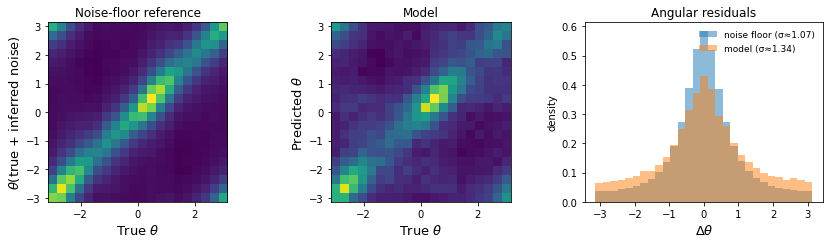

In [228]:
# Noise-floor reference for the angle plot.
# Compares true theta against theta(true + inferred noise), NOT theta(pred + noise).
# This shows the angular scatter you would see even for a perfect model, given the
# inferred per-component noise (sigma_x, sigma_y). Compare this panel directly
# against your existing "true theta vs predicted theta" heatmap.

rng = np.random.default_rng(0)
n_draws = 20  # multiple noise draws per point to smooth the reference distribution

sigma_x, sigma_y = Overall_noise['per_dim_std']


ax_true = targets[:, 0]
ay_true = targets[:, 1]

# Tile targets n_draws times and add independent Gaussian noise per component.
ax_tiled = np.repeat(ax_true, n_draws)
ay_tiled = np.repeat(ay_true, n_draws)
ax_noisy = ax_tiled + rng.normal(0.0, sigma_x, size=ax_tiled.shape)
ay_noisy = ay_tiled + rng.normal(0.0, sigma_y, size=ay_tiled.shape)

theta_true       = np.arctan2(ay_true,  ax_true)
theta_true_rep   = np.repeat(theta_true, n_draws)
theta_true_noisy = np.arctan2(ay_noisy, ax_noisy)

# Magnitude mask (angle is ill-defined for tiny |a|) — match your earlier amin choice.
amin = 0.0
a_mag_rep = np.sqrt(ax_tiled**2 + ay_tiled**2)
#valid = a_mag_rep > amin

amin = 0.0
amax = 6.0
#a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
valid = (a_mag_rep > amin) & (a_mag_rep < amax)
fraction_valid = np.sum(valid) / len(valid)
print(fraction_valid)


# Also prepare the predicted-theta heatmap for side-by-side comparison.
theta_pred = np.arctan2(predictions[:, 1], predictions[:, 0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
valid_pred = (a_mag > amin) & (a_mag < amax)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))

# (0) Noise-floor reference: true vs true+noise
h0, xe, ye = np.histogram2d(theta_true_rep[valid], theta_true_noisy[valid],
                            bins=20, range=[[-np.pi, np.pi], [-np.pi, np.pi]])
ax[0].imshow(h0.T, extent=[-np.pi, np.pi, -np.pi, np.pi],
             origin='lower', cmap='viridis', aspect='equal')
ax[0].set_xlabel(r'True $\theta$', fontsize=13)
ax[0].set_ylabel(r'$\theta$(true + inferred noise)', fontsize=13)
ax[0].set_title('Noise-floor reference')

# (1) Model performance: true vs predicted
h1, _, _ = np.histogram2d(theta_true[valid_pred], theta_pred[valid_pred],
                          bins=20, range=[[-np.pi, np.pi], [-np.pi, np.pi]])
ax[1].imshow(h1.T, extent=[-np.pi, np.pi, -np.pi, np.pi],
             origin='lower', cmap='viridis', aspect='equal')
ax[1].set_xlabel(r'True $\theta$', fontsize=13)
ax[1].set_ylabel(r'Predicted $\theta$', fontsize=13)
ax[1].set_title('Model')

# (2) Residual distributions overlaid (wrapped to [-pi, pi]).
def wrap(d):
    return (d + np.pi) % (2 * np.pi) - np.pi

dtheta_ref   = wrap(theta_true_noisy[valid] - theta_true_rep[valid])
dtheta_model = wrap(theta_pred[valid_pred] - theta_true[valid_pred])
bins = np.linspace(-np.pi, np.pi, 30)
ax[2].hist(dtheta_ref,   bins=bins, density=True, alpha=0.5,
           label=f'noise floor (σ≈{np.std(dtheta_ref):.2f})')
ax[2].hist(dtheta_model, bins=bins, density=True, alpha=0.5,
           label=f'model (σ≈{np.std(dtheta_model):.2f})')
ax[2].set_xlabel(r'$\Delta\theta$', fontsize=13)
ax[2].set_ylabel('density')
ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title('Angular residuals')

fig.tight_layout()
plt.show()

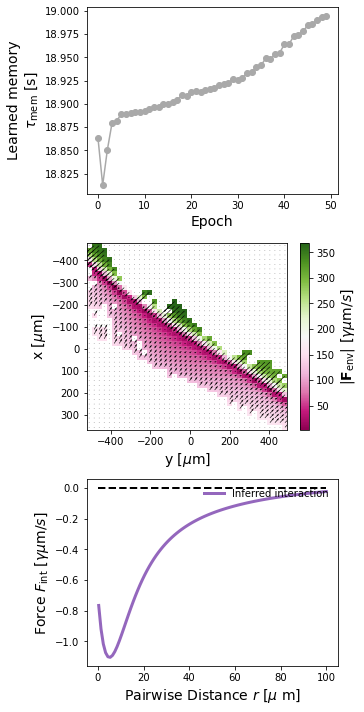

In [229]:
# plot loss
kappa0 = 0
fig,ax=plt.subplots(3,1,figsize = (5,10))

ax[0].plot(np.multiply(history['tau_raw'],60),color = 'darkgrey',linestyle = '-',label = 'Learned memory',marker = 'o')
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel("Learned memory\n"+r"$\tau_{\mathrm{mem}}$ [s]",fontsize = 14)

F_mag_infer = np.where(sparse_mask, np.nan, np.linalg.norm(F_infer, axis=2))
F_vec = F_infer.copy(); F_vec[sparse_mask] = 0.0


pcm = ax[1].pcolormesh(X, Y, F_mag_infer, shading='auto', cmap='PiYG')
cbar = fig.colorbar(pcm, ax=ax[1])
cbar.set_label(r'$|\mathbf{F_{\mathrm{env}}}|~[\gamma\mu\mathrm{m}/s]$',fontsize = 14)

# === 3) Quiver on top ===
# (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 30, 1)
sy = max(len(y_arr) // 30, 1)

ax[1].quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    F_vec[::sx, ::sy, 0],
    F_vec[::sx, ::sy, 1],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=5,   # or a number if you want to shrink arrows
    width=0.003
)

# === 4) Axes labels / ticks ===
ax[1].set_xlabel('y [$\mu$m]',fontsize = 14)
ax[1].set_ylabel('x [$\mu$m]',fontsize = 14)
ax[1].invert_yaxis()
ax[2].plot(r_arr_plot,np.multiply(force_infer,scaleF),color = 'tab:purple',linestyle = '-',linewidth = 3,label = 'Inferred interaction')
ax[2].set_xlabel(r'Pairwise Distance $r$ [$\mu$ m]',fontsize = 14)
ax[2].set_ylabel(r'Force $F_{\mathrm{int}}$ [$\gamma\mu$m$/s$]',fontsize = 14)
ax[2].plot([0,r_cut],[0,0],color = 'black',linestyle = '--',linewidth = 2)
ax[2].legend(frameon = False,loc = 'upper right')
fig.tight_layout()

In [230]:
# Run this before the _summarise call to see what's happening
mask_values = []
for dp in val_data:
    if 'mask' in dp:
        mask_values.extend(dp['mask'].tolist() if hasattr(dp['mask'], 'tolist') else list(dp['mask']))

mask_arr = np.array(mask_values)
print(f"Total mask entries: {len(mask_arr)}")
print(f"Unique values in mask: {np.unique(mask_arr)}")
print(f"dtype: {mask_arr.dtype}")
print(f"Count == 1.0 : {np.sum(mask_arr == 1.0)}")
print(f"Count == 1   : {np.sum(mask_arr == 1)}")
print(f"Count  > 0   : {np.sum(mask_arr > 0)}")
print(f"Sample values: {mask_arr[:20]}")

Total mask entries: 7619
Unique values in mask: [False  True]
dtype: bool
Count == 1.0 : 4669
Count == 1   : 4669
Count  > 0   : 4669
Sample values: [ True False  True  True  True False  True  True  True  True False False
  True  True  True  True  True  True  True False]


In [231]:
Data_Fine_UD = evaluate_model_frames(model,__,verbose = False)


Using 29293 / 31337 rows  (93.5%) for noise distribution analysis.

Moments of the residual distribution (normalised acceleration units):
eta_x shape: (29293,), eta_y shape: (29293,)
Any NaN: False, Any Inf: False
eta_x : n=29293  mean=-0.0098  std=1.0368  skew=+0.043  excess kurtosis=+0.711
        Anderson–Darling A² = 45.95  (critical at 1% sig level: 1.09; larger ⇒ reject Gaussian)
eta_y : n=29293  mean=+0.0000  std=0.9399  skew=+0.013  excess kurtosis=+1.001
        Anderson–Darling A² = 88.36  (critical at 1% sig level: 1.09; larger ⇒ reject Gaussian)


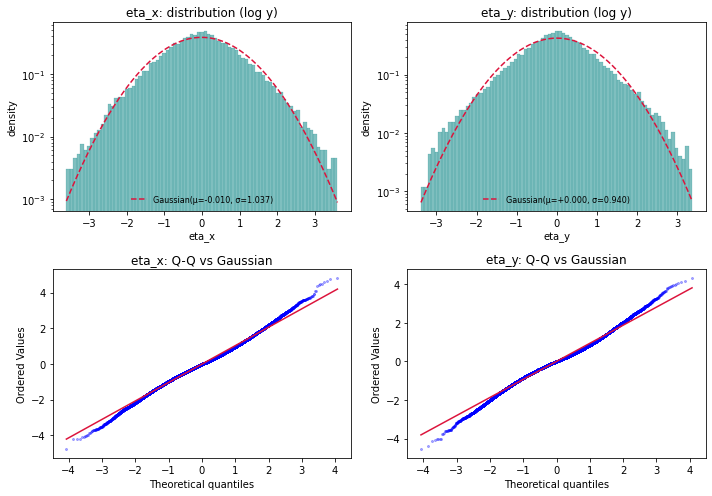

1.204815746569168


In [232]:
# ------------------------------------------------------------------
# Noise analysis Step 1: distribution of η = target − prediction
# in normalised acceleration units.
# Self-contained: computes the "honest cells" filter inline.
# ------------------------------------------------------------------
from scipy import stats as _scistats

_df = Data_Fine_UD

# --- Compute filter inline (no dependency on previous cells) -----
MIN_TRACK_LENGTH = 10
_first_frame = _df.groupby('node_id')['frame'].transform('min')
_last_frame  = _df.groupby('node_id')['frame'].transform('max')
_track_length = _last_frame - _first_frame + 1
_dataset_first = _df['frame'].min()
_dataset_last  = _df['frame'].max()
_is_edge_start = (_first_frame == _dataset_first)
_is_edge_end   = (_last_frame  == _dataset_last)
#mask = (~_is_edge_start) & (~_is_edge_end) & (_track_length >= MIN_TRACK_LENGTH)
mask = _track_length >= MIN_TRACK_LENGTH
sub = _df[mask]
print(f"Using {mask.sum()} / {len(_df)} rows  "
      f"({100*mask.mean():.1f}%) for noise distribution analysis.")

# Per-row noise: η = target − prediction, in normalised units.
eta_x = (sub['target_x'] - sub['pred_x']).to_numpy()
eta_y = (sub['target_y'] - sub['pred_y']).to_numpy()

# --- Moments and normality stats --------------------------------
def _summarise(label, e):
    e = np.asarray(e).ravel()
    n = len(e)
    
    if n == 0:
        print(f"{label:6s}: no samples (empty array — check mask)")
        return np.nan, np.nan
    if n < 8:   # Anderson-Darling is unreliable below ~8 samples
        print(f"{label:6s}: n={n}  too few samples for Anderson-Darling test")
        mu, sd = np.mean(e), np.std(e, ddof=1)
        return mu, sd

    mu  = np.mean(e)
    sd  = np.std(e, ddof=1)
    sk  = _scistats.skew(e)
    ku  = _scistats.kurtosis(e, fisher=True)
    ad  = _scistats.anderson(e, dist='norm')
    print(f"{label:6s}: n={n}  mean={mu:+.4f}  std={sd:.4f}  "
          f"skew={sk:+.3f}  excess kurtosis={ku:+.3f}")
    print(f"        Anderson–Darling A² = {ad.statistic:.2f}  "
          f"(critical at 1% sig level: {ad.critical_values[-1]:.2f}; "
          f"larger ⇒ reject Gaussian)")
    return mu, sd

print("\nMoments of the residual distribution (normalised acceleration units):")
print(f"eta_x shape: {eta_x.shape}, eta_y shape: {eta_y.shape}")
print(f"Any NaN: {np.any(np.isnan(eta_x))}, Any Inf: {np.any(np.isinf(eta_x))}")
mu_x, sd_x = _summarise('eta_x', eta_x)
mu_y, sd_y = _summarise('eta_y', eta_y)

# --- Plot: histograms with Gaussian overlay + Q-Q plots ---------
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax_i, (label, e, mu, sd) in enumerate([('eta_x', eta_x, mu_x, sd_x),
                                            ('eta_y', eta_y, mu_y, sd_y)]):
    ax = axes[0, ax_i]
    bins = np.linspace(np.percentile(e, 0.1), np.percentile(e, 99.9), 80)
    ax.hist(e, bins=bins, density=True, color='teal', alpha=0.5,
            edgecolor='teal', lw=0.3)
    xs = np.linspace(bins[0], bins[-1], 400)
    gauss = np.exp(-0.5 * ((xs - mu) / sd)**2) / (sd * np.sqrt(2 * np.pi))
    ax.plot(xs, gauss, '--', color='crimson', lw=1.5,
            label=f'Gaussian(μ={mu:+.3f}, σ={sd:.3f})')
    ax.set_xlabel(label)
    ax.set_ylabel('density')
    ax.legend(frameon=False, fontsize=8)
    ax.set_yscale('log')
    ax.set_title(f'{label}: distribution (log y)')

    ax = axes[1, ax_i]
    _scistats.probplot(e, dist='norm', plot=ax)
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_alpha(0.3)
    ax.get_lines()[1].set_color('crimson')
    ax.set_title(f'{label}: Q-Q vs Gaussian')

fig.tight_layout()
plt.show()
print(sub['target_x'].std())

Using 29293 rows from 968 particles.
Computed autocorrelations across 690 trajectories.


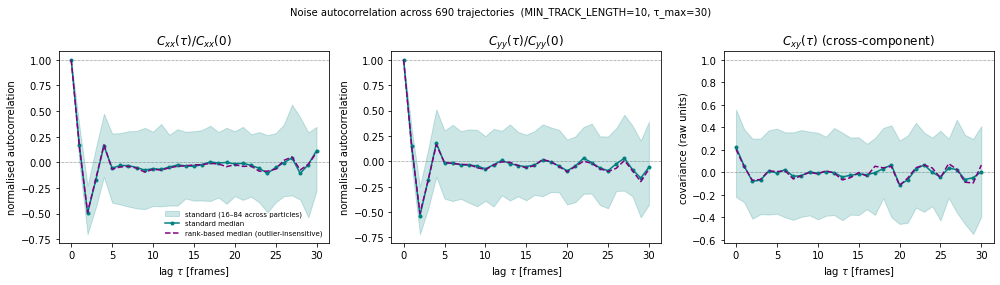


Key-lag summary (median across particles):
  τ=  0: C_xx=+1.000  C_yy=+1.000  C_xy=+0.224    (n_particles=690)
  τ=  1: C_xx=+0.168  C_yy=+0.151  C_xy=+0.056    (n_particles=690)
  τ=  2: C_xx=-0.495  C_yy=-0.537  C_xy=-0.080    (n_particles=690)
  τ=  5: C_xx=-0.056  C_yy=-0.019  C_xy=-0.004    (n_particles=690)
  τ= 10: C_xx=-0.062  C_yy=-0.075  C_xy=-0.008    (n_particles=552)
  τ= 20: C_xx=-0.015  C_yy=-0.094  C_xy=-0.110    (n_particles=180)


In [233]:
# ------------------------------------------------------------------
# Noise analysis Step 2: autocorrelation function of η = target − pred.
# Per particle, then averaged across particles. Computed as both the
# standard estimator (sensitive to heavy tails) and a rank-based
# version (insensitive to tails). Three components: C_xx, C_yy, C_xy.
# Self-contained — recomputes the "honest cells" filter inline.
# ------------------------------------------------------------------
from scipy import stats as _scistats

_df = Data_Fine_UD

# --- Filter: same as Step 1 -------------------------------------
MIN_TRACK_LENGTH = 10
TAU_MAX = 30
MIN_PARTICLES_PER_LAG = 5     # discard lag estimates with fewer than this many particles

_first_frame = _df.groupby('node_id')['frame'].transform('min')
_last_frame  = _df.groupby('node_id')['frame'].transform('max')
_track_length = _last_frame - _first_frame + 1
_dataset_first = _df['frame'].min()
_dataset_last  = _df['frame'].max()
_is_edge_start = (_first_frame == _dataset_first)
_is_edge_end   = (_last_frame  == _dataset_last)
#mask = (~_is_edge_start) & (~_is_edge_end) & (_track_length >= MIN_TRACK_LENGTH)
mask = _track_length >= MIN_TRACK_LENGTH

sub = _df[mask].copy()
sub['eta_x'] = sub['target_x'] - sub['pred_x']
sub['eta_y'] = sub['target_y'] - sub['pred_y']
print(f"Using {len(sub)} rows from {sub['node_id'].nunique()} particles.")

# --- Per-particle autocorrelation -------------------------------
def _trajectory_autocorr(eta_a, eta_b, tau_max):
    """
    Compute C_ab(τ) = ⟨ η_a(t) η_b(t+τ) ⟩ along a single trajectory.
    Returns array of length tau_max+1 (NaN where trajectory too short).
    Mean of each series is subtracted first (per-trajectory zero-mean).
    """
    a = eta_a - np.mean(eta_a)
    b = eta_b - np.mean(eta_b)
    n = len(a)
    out = np.full(tau_max + 1, np.nan)
    for tau in range(tau_max + 1):
        if n - tau < 2:
            break
        out[tau] = np.mean(a[: n - tau] * b[tau:])
    return out

# Containers: rows = particles, cols = τ.
particle_ids = []
C_xx_per = []
C_yy_per = []
C_xy_per = []
C_xx_rank_per = []
C_yy_rank_per = []
C_xy_rank_per = []

for pid, traj in sub.sort_values(['node_id', 'frame']).groupby('node_id'):
    # Frame continuity check: only keep contiguous tracks for clean lag definition.
    frames = traj['frame'].to_numpy()
    if not np.all(np.diff(frames) == 1):
        # If the trajectory has gaps, split into contiguous runs and use the
        # longest. (Could alternatively use all runs; the simplest honest choice.)
        breaks = np.where(np.diff(frames) != 1)[0] + 1
        runs = np.split(np.arange(len(frames)), breaks)
        run = max(runs, key=len)
        traj = traj.iloc[run]
        if len(traj) < MIN_TRACK_LENGTH:
            continue

    ex = traj['eta_x'].to_numpy()
    ey = traj['eta_y'].to_numpy()
    rx = _scistats.rankdata(ex)               # rank-based: insensitive to outliers
    ry = _scistats.rankdata(ey)

    C_xx_per.append(_trajectory_autocorr(ex, ex, TAU_MAX))
    C_yy_per.append(_trajectory_autocorr(ey, ey, TAU_MAX))
    C_xy_per.append(_trajectory_autocorr(ex, ey, TAU_MAX))
    C_xx_rank_per.append(_trajectory_autocorr(rx, rx, TAU_MAX))
    C_yy_rank_per.append(_trajectory_autocorr(ry, ry, TAU_MAX))
    C_xy_rank_per.append(_trajectory_autocorr(rx, ry, TAU_MAX))
    particle_ids.append(pid)

C_xx_per = np.array(C_xx_per)
C_yy_per = np.array(C_yy_per)
C_xy_per = np.array(C_xy_per)
C_xx_rank_per = np.array(C_xx_rank_per)
C_yy_rank_per = np.array(C_yy_rank_per)
C_xy_rank_per = np.array(C_xy_rank_per)

print(f"Computed autocorrelations across {len(particle_ids)} trajectories.")

# --- Aggregate across particles ---------------------------------
def _agg(per_particle):
    """Returns mean, median, 16th, 84th percentiles, n at each lag (NaN-safe)."""
    out = {}
    out['mean']   = np.nanmean(per_particle, axis=0)
    out['median'] = np.nanmedian(per_particle, axis=0)
    out['lo']     = np.nanpercentile(per_particle, 16, axis=0)
    out['hi']     = np.nanpercentile(per_particle, 84, axis=0)
    out['n']      = np.sum(np.isfinite(per_particle), axis=0)
    return out

# Normalise C(τ) by C(0) within each particle so all curves start at 1
# (for the autocorrelation panels). For the cross-correlation we don't
# normalise — its scale is meaningful.
def _normalise_per_particle(per_particle):
    norm = per_particle[:, 0:1].copy()
    norm[norm == 0] = np.nan
    return per_particle / norm

def _normalise_cross(per_particle_xy, per_particle_xx, per_particle_yy):
    """Pearson-style normalisation: C_xy(τ) / sqrt(C_xx(0) * C_yy(0)) per particle."""
    norm = np.sqrt(per_particle_xx[:, 0:1] * per_particle_yy[:, 0:1])
    norm[norm <= 0] = np.nan
    return per_particle_xy / norm

C_xy_norm    = _normalise_cross(C_xy_per,      C_xx_per,      C_yy_per)
C_xy_rk_norm = _normalise_cross(C_xy_rank_per, C_xx_rank_per, C_yy_rank_per)

agg_xy    = _agg(C_xy_norm)
agg_xy_rk = _agg(C_xy_rk_norm)

C_xx_norm     = _normalise_per_particle(C_xx_per)
C_yy_norm     = _normalise_per_particle(C_yy_per)
C_xx_rk_norm  = _normalise_per_particle(C_xx_rank_per)
C_yy_rk_norm  = _normalise_per_particle(C_yy_rank_per)

agg_xx     = _agg(C_xx_norm)
agg_yy     = _agg(C_yy_norm)
#agg_xy     = _agg(C_xy_per)        # not normalised
agg_xx_rk  = _agg(C_xx_rk_norm)
agg_yy_rk  = _agg(C_yy_rk_norm)
#agg_xy_rk  = _agg(C_xy_rank_per)

# --- Plot ---------------------------------------------------------
taus = np.arange(TAU_MAX + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def _plot_panel(ax, agg_std, agg_rk, title, ylabel, normalise_to_one=True):
    valid = agg_std['n'] >= MIN_PARTICLES_PER_LAG

    # Standard estimator: median + 16/84 band (median is more robust than mean).
    ax.fill_between(taus[valid], agg_std['lo'][valid], agg_std['hi'][valid],
                    color='teal', alpha=0.2, zorder=2,
                    label='standard (16–84 across particles)')
    ax.plot(taus[valid], agg_std['median'][valid], '-o', color='teal',
            markersize=3, lw=1.5, zorder=3, label='standard median')

    # Rank-based: dashed line, no band (would clutter).
    ax.plot(taus[valid], agg_rk['median'][valid], '--', color='purple',
            lw=1.5, zorder=4, label='rank-based median (outlier-insensitive)')

    ax.axhline(0, color='k', lw=0.5, ls=':', zorder=1)
    if normalise_to_one:
        ax.axhline(1, color='k', lw=0.5, ls=':', zorder=1)
    ax.set_xlabel(r'lag $\tau$ [frames]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

_plot_panel(axes[0], agg_xx,    agg_xx_rk,
            r'$C_{xx}(\tau) / C_{xx}(0)$', 'normalised autocorrelation',
            normalise_to_one=True)
_plot_panel(axes[1], agg_yy,    agg_yy_rk,
            r'$C_{yy}(\tau) / C_{yy}(0)$', 'normalised autocorrelation',
            normalise_to_one=True)
_plot_panel(axes[2], agg_xy,    agg_xy_rk,
            r'$C_{xy}(\tau)$ (cross-component)',
            'covariance (raw units)', normalise_to_one=True)

axes[0].legend(frameon=False, fontsize=7, loc='best')
fig.suptitle(f'Noise autocorrelation across {len(particle_ids)} trajectories  '
             f'(MIN_TRACK_LENGTH={MIN_TRACK_LENGTH}, τ_max={TAU_MAX})',
             fontsize=10)
fig.tight_layout()
plt.show()

# --- Quick numerical summary at key lags ------------------------
def _at(agg, tau):
    return agg['median'][tau], agg['n'][tau]

print(f"\nKey-lag summary (median across particles):")
for tau in [0, 1, 2, 5, 10, 20]:
    if tau > TAU_MAX:
        continue
    m_xx, n_xx = _at(agg_xx, tau)
    m_yy, n_yy = _at(agg_yy, tau)
    m_xy, n_xy = _at(agg_xy, tau)
    print(f"  τ={tau:3d}: C_xx={m_xx:+.3f}  C_yy={m_yy:+.3f}  "
          f"C_xy={m_xy:+.3f}    (n_particles={n_xx})")